<h1>Assignment 2: <strong> MLP and Backpropagation</strong></h1>
Name : Sammit Poudyal <br/>
Class : CE 2022<br/>
Registration Number : 032329-22<br>
Date : 12/04/2026<br/>
Dataset Used :<strong> Fashion-MNIST </strong><br/>


## 1. Objectives
- Implement a Multilayer Perceptron (MLP) using PyTorch for image classification.  
- Construct a training loop with forward pass, loss computation, and backpropagation.  
- Analyze and evaluate the effect of learning rate on model convergence speed and final performance.
- Visualize training process through loss curves and accuracy metrics.
- Compare manual backpropagation gradients with PyTorch autograd for verification.

## 2.Theoretical Background
### 2.1 Multilayer Perceptron (MLP):
In deep learning, a **multilayer perceptron (MLP)** is a kind of modern feedforward neural network consisting of fully connected neurons with nonlinear activation functions, organized in layers, notable for being able to distinguish data that is not linearly separable.
- It consists a layer of an input layer which receives the raw features, followed by one or more hidden layers that learn intermediate representations and an output layer to produce the final prediction.
- It is a feedforward neural network composed of one or more hidden layers with non-linear activation functions. For classification, the final layer typically uses a softmax activation.

For a single-hidden-layer MLP:
- Input: $X \in \mathbb{R}^{n \times d}$ [n samples, d features]
- Hidden layer: $H = \sigma(XW^{(1)} + b^{(1)})$, $W^{(1)} \in \mathbb{R}^{d \times h}$
- Output layer: $O = HW^{(2)} + b^{(2)}$, $W^{(2)} \in \mathbb{R}^{h \times q}$
- Prediction: $\hat{y} = \text{softmax}(O)$ for classification

### 2.2 Activation Functions: 
- Functions that are applied after each layer's linear transformation to introduce non-linearity into the network, enabling network to learn complex, non-linear patterns.
- **ReLU**: $\sigma(x) = \max(0, x)$
  - Derivative: $\sigma'(x) = 1$ if $x > 0$, else $0$
  - Advantages: Computationally efficient, mitigates vanishing gradients.

### 2.3 Loss Function: Cross-Entropy
Cross Entropy measures the performance of a classification model by calculating the divergence between predicted probability distributions and actual class labels. <br/>
For multi-class classification with true label $y$ and predicted logits $z$:
$$L = -\log\left(\frac{\exp(z_y)}{\sum_j \exp(z_j)}\right)$$

PyTorch: <strong>nn.CrossEntropyLoss()</strong> combines LogSoftmax + NLLLoss

### 2.4 Backpropagation Algorithm
Backpropagation computes gradients via the chain rule ( output -> input )
1. Forward pass: Compute predictions and loss
2. Backward pass: 
   - Compute $\partial L/\partial O$ at output layer
   - Propagate backwards: $\partial L/\partial W^{(l)} = (\partial L/\partial H^{(l)}) \times (\partial H^{(l)}/\partial W^{(l)})$
- **Output Gradient:** $\frac{\partial \mathcal{L}}{\partial \hat{Y}} = \text{softmax}(\hat{Y}) - Y_{\text{one-hot}}$
- Enables exact gradient computation in $O(\text{parameters})$ time, avoiding finite-difference approximations.


### 2.5 Optimization: SGD with Momentum
- **Vanilla SGD:** $\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}$ (step size = learning rate $\eta$)
- **Momentum:** Accumulates historical gradients to dampen oscillations & accelerate convergence
  - Velocity: $v_t = \mu v_{t-1} + \eta \nabla_\theta \mathcal{L}$
  - Update: $\theta \leftarrow \theta - v_t$
- Typical $\mu = 0.9$; balances responsiveness with update stability.

### 2.6 PyTorch Autograd Engine
- Dynamically tracks operations during the forward pass to build a **computational graph**
- <strong>loss.backward()</strong> traverses the graph in reverse, applying the chain rule automatically.
- <strong>optimizer.step()</strong> applies computed gradients; <strong>optimizer.zero_grad()</strong> clears accumulated gradients before the next batch.

## 3. Dataset Description

**Dataset:** Fashion-MNIST  
**Source:** Zalando Research (https://github.com/zalandoresearch/fashion-mnist)  
**Description:** 70,000 grayscale images of fashion products across 10 categories  
**Image Size:** 28×28 pixels (784 features when flattened)  
**Classes:** 10 clothing categories (T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot)  
**Split Strategy:** 
- Training: 90% of train set (~54,000 samples)
- Validation: 10% of train set (~6,000 samples)  
- Test: Full test set (10,000 samples)

**Preprocessing:**
- Converted to tensors [0, 1]
- Normalized with dataset mean=0.2860, std=0.3530



## 4. Implementation

### 4.1 Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
import pandas as pd
warnings.filterwarnings('ignore')

# Set random seeds
def set_seed(seed=20):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    print(f" Random seed set to {seed}")

set_seed(20)

#Printing used device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Using device: {DEVICE}")

 Random seed set to 20
  Using device: cpu


### 4.2 Downloading Dataset

In [2]:
# Configuration
DATA_DIR = './data'
BATCH_SIZE = 64
INPUT_SIZE = 28*28  # Flattened 28x28 images
HIDDEN_SIZE = 256
OUTPUT_SIZE = 10    # 10 clothing categories

# Transform pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # Fashion-MNIST stats
])

# Load datasets
print("Loading Fashion-MNIST dataset...")
train_full = datasets.FashionMNIST(
    root=DATA_DIR, train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root=DATA_DIR, train=False, download=True, transform=transform
)

# Split training data for validation
train_size = int(0.9 * len(train_full))
val_size = len(train_full) - train_size
train_dataset, val_dataset = random_split(
    train_full, [train_size, val_size], 
    generator=torch.Generator().manual_seed(42)
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Dataset statistics
print(f"\n Dataset Statistics:")
print(f"• Training samples: {len(train_dataset):,}")
print(f"• Validation samples: {len(val_dataset):,}")
print(f"• Test samples: {len(test_dataset):,}")
print(f"• Input dimensions: {INPUT_SIZE} (28×28 flattened)")
print(f"• Number of classes: {OUTPUT_SIZE}")
print(f"• Batch size: {BATCH_SIZE}")

# Class labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Loading Fashion-MNIST dataset...


100.0%
100.0%
100.0%
100.0%


 Dataset Statistics:
• Training samples: 54,000
• Validation samples: 6,000
• Test samples: 10,000
• Input dimensions: 784 (28×28 flattened)
• Number of classes: 10
• Batch size: 64


### 4.3 Dataset Visualization & Exploration

 Fashion-MNIST Dataset


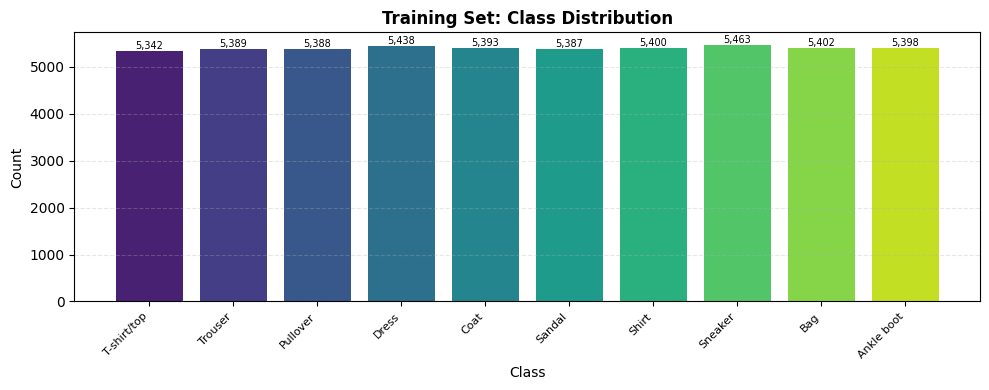

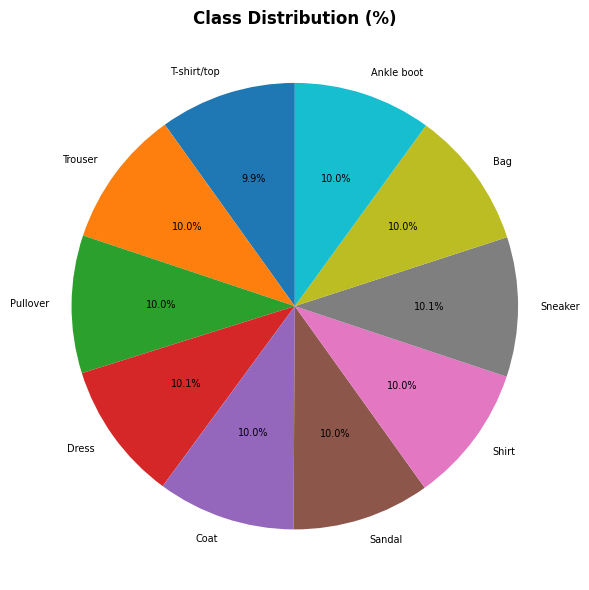


 Sample Images from Each Class (28×28):


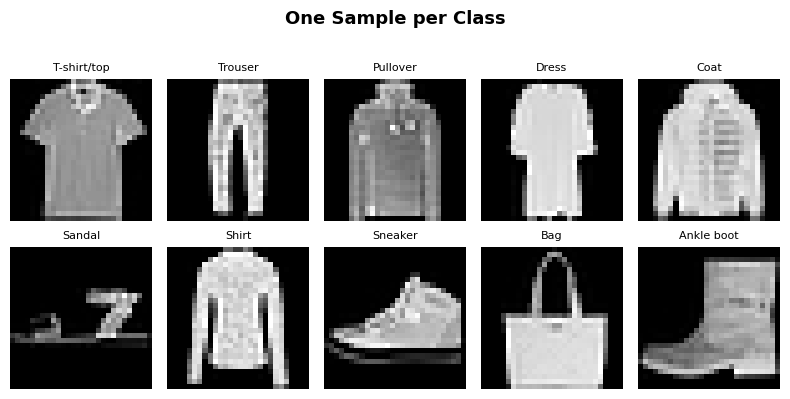


 Dataset Statistics:
      Class  Count  Percentage
T-shirt/top   5342        9.89
    Trouser   5389        9.98
   Pullover   5388        9.98
      Dress   5438       10.07
       Coat   5393        9.99
     Sandal   5387        9.98
      Shirt   5400       10.00
    Sneaker   5463       10.12
        Bag   5402       10.00
 Ankle boot   5398       10.00


In [3]:

print(" Fashion-MNIST Dataset")

# Class Distribution (Bar Chart) 
train_labels = [label for _, label in train_dataset]
label_counts = np.bincount(train_labels, minlength=10)

plt.figure(figsize=(10, 4))
bars = plt.bar(class_names, label_counts, color=sns.color_palette("viridis", 10))
plt.xlabel('Class', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.title('Training Set: Class Distribution', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', 
             ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

# Class Distribution (Pie Chart) 
plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=class_names, autopct='%1.1f%%', 
        startangle=90, textprops={'fontsize': 7})
plt.title('Class Distribution (%)', fontsize=12, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

#  Sample Images Grid (Small, 2x5)
print("\n Sample Images from Each Class (28×28):")
fig, axes = plt.subplots(2, 5, figsize=(8, 4))
axes = axes.ravel()

# Get one sample per class
samples_per_class = {}
for img, label in train_dataset:
    if label not in samples_per_class and len(samples_per_class) < 10:
        samples_per_class[label] = img
    if len(samples_per_class) == 10:
        break

for class_idx in range(10):
    img = samples_per_class[class_idx]
    axes[class_idx].imshow(img.squeeze(), cmap='gray')
    axes[class_idx].set_title(f'{class_names[class_idx]}', fontsize=8)
    axes[class_idx].axis('off')

plt.suptitle('One Sample per Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#  Quick Statistics Table 
stats_df = pd.DataFrame({
    'Class': class_names,
    'Count': label_counts,
    'Percentage': (label_counts / len(train_labels) * 100).round(2)
})
print("\n Dataset Statistics:")
print(stats_df.to_string(index=False))


### 4.4 MLP Model Definition (PyTorch)

In [4]:
class MLP(nn.Module):
    #Multilayer Perceptron for image classification.
    #Arch: Input (784) -> Hidden (256, ReLU) ->  Output (10)
    def __init__(self, input_size, hidden_size, output_size, dropout_rate=0.2):
        super(MLP, self).__init__()
        
        # L1: Input -> Hidden
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)
        
        # L2: Hidden -> Output
        self.fc2 = nn.Linear(hidden_size, output_size)
        # Note: No activation; CrossEntropyLoss expects raw logits
        
    def forward(self, x):
        # Flatten input if needed (for image data)
        if x.dim() > 2:
            x = x.view(x.size(0), -1)
        
        # Forward pass through layers
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        
        return x
    
    def count_parameters(self):
        # for counting trainable parameters
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Initialize model
model = MLP(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE)
model = model.to(DEVICE)

print(f"\n Model initialized")
print(f" Total trainable parameters: {model.count_parameters():,}")
print(f" Model architecture:\n{model}")


 Model initialized
 Total trainable parameters: 203,530
 Model architecture:
MLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


### 4.5 Training Loop Components

In [5]:
def train_epoch(model, loader, criterion, optimizer, device):
    #Single training epoch: forward pass -> loss -> backward pass -> update
    #Return average loss and accuracy for the epoch
    
    model.train()  # Training mode (enables dropout)
    epoch_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(loader):
        # Move data to device
        images, labels = images.to(device), labels.to(device)
        
        # ===== FORWARD PASS =====
        outputs = model(images)  # Compute predictions
        loss = criterion(outputs, labels)  # Compute loss
        
        # ===== BACKWARD PASS =====
        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()  # Compute gradients via backpropagation
        optimizer.step()  # Update weights
        
        # Track metrics
        epoch_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    avg_loss = epoch_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    #Evaluate model on validation/test set (no gradient computation)

    model.eval()  # Evaluation mode (disables dropout)
    epoch_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():  # Disable gradient tracking
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass only
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Track metrics
            epoch_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Store for detailed analysis
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = epoch_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy, all_preds, all_labels

## 5.Experiments

### 5.1 Base Model Training

In [6]:
print("\n" + " " * 60)
print("EXPERIMENT 1: Base Model Training")
print(" " * 60)

# Hyperparameters
LEARNING_RATE = 0.001
NUM_EPOCHS = 25
MOMENTUM = 0.9

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

# Training history storage
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

# Training loop
print(f"\nTraining for {NUM_EPOCHS} epochs...")
print(f"Learning rate: {LEARNING_RATE}, Momentum: {MOMENTUM}\n")

for epoch in range(NUM_EPOCHS):
    # Training phase
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )
    
    # Validation phase
    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Progress output
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

print("\n Training completed!")


                                                            
EXPERIMENT 1: Base Model Training
                                                            

Training for 25 epochs...
Learning rate: 0.001, Momentum: 0.9

Epoch [ 5/25] | Train Loss: 0.4113, Acc: 85.31% | Val Loss: 0.4119, Acc: 85.40%
Epoch [10/25] | Train Loss: 0.3552, Acc: 87.30% | Val Loss: 0.3617, Acc: 86.90%
Epoch [15/25] | Train Loss: 0.3216, Acc: 88.47% | Val Loss: 0.3479, Acc: 87.43%
Epoch [20/25] | Train Loss: 0.2984, Acc: 89.43% | Val Loss: 0.3265, Acc: 88.45%
Epoch [25/25] | Train Loss: 0.2802, Acc: 89.99% | Val Loss: 0.3153, Acc: 88.67%

 Training completed!


#### 5.1.1 Visualization of Training History


 Generating training history plots...


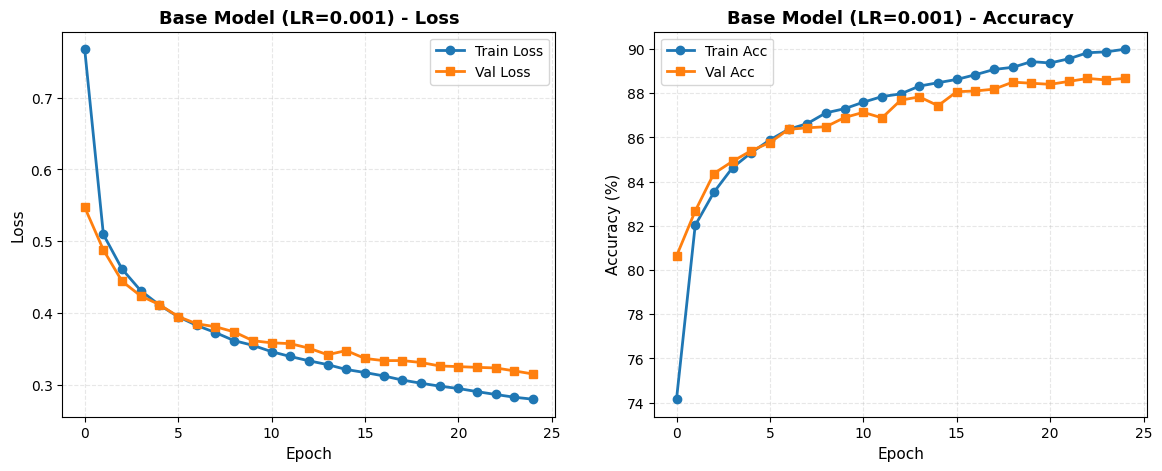

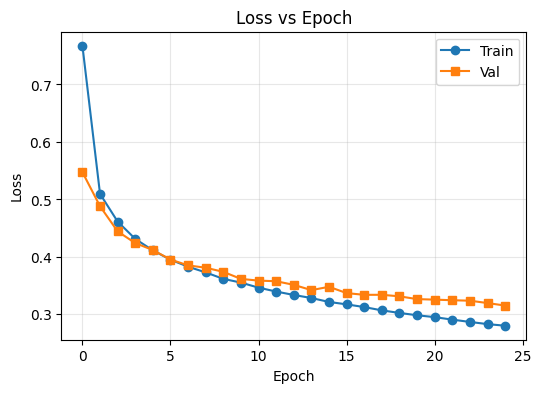

<Figure size 640x480 with 0 Axes>

In [7]:
def plot_training_history(history, title="Training History"):
    #Ploting loss and accuracy curves for training and validation sets.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Loss', fontsize=11)
    axes[0].set_title(f'{title} - Loss', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3, linestyle='--')
    
    # Accuracy plot
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Accuracy (%)', fontsize=11)
    axes[1].set_title(f'{title} - Accuracy', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3, linestyle='--')

    # Optional: Separate loss-only plot
    plt.figure(figsize=(6, 4))
    plt.plot(history['train_loss'], label='Train', marker='o')
    plt.plot(history['val_loss'], label='Val', marker='s')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss vs Epoch')
    plt.legend(); plt.grid(alpha=0.3); plt.show()
    
    plt.tight_layout()
    return fig

# Plot training history
print("\n Generating training history plots...")
fig1 = plot_training_history(history, "Base Model (LR=0.001)")
plt.show()

### 5.2 Learning Rate Sensitivity Analysis

In [8]:
print("\n" + " " * 60)
print("EXPERIMENT 2: Learning Rate Sensitivity Analysis")
print(" " * 60)

# Learning rates to compare
learning_rates = [0.1, 0.01, 0.001, 0.0001]
lr_results = {}

for lr in learning_rates:
    print(f"\n ... Testing learning rate: {lr}")
    
    # Re-initialize model for fair comparison
    model_lr = MLP(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE).to(DEVICE)
    optimizer_lr = optim.SGD(model_lr.parameters(), lr=lr, momentum=MOMENTUM)
    
    # Short training run (5 epochs for comparison)
    lr_history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(5):
        train_loss, _ = train_epoch(
            model_lr, train_loader, criterion, optimizer_lr, DEVICE
        )
        val_loss, _, _, _ = evaluate(
            model_lr, val_loader, criterion, DEVICE
        )
        lr_history['train_loss'].append(train_loss)
        lr_history['val_loss'].append(val_loss)
    
    lr_results[lr] = lr_history
    print(f"  Final train loss: {train_loss:.4f}, val loss: {val_loss:.4f}")


                                                            
EXPERIMENT 2: Learning Rate Sensitivity Analysis
                                                            

 ... Testing learning rate: 0.1
  Final train loss: 1.1324, val loss: 0.7491

 ... Testing learning rate: 0.01
  Final train loss: 0.3091, val loss: 0.3358

 ... Testing learning rate: 0.001
  Final train loss: 0.4132, val loss: 0.4100

 ... Testing learning rate: 0.0001
  Final train loss: 0.6569, val loss: 0.6345


#### 5.2.1 Plot LR Comparision

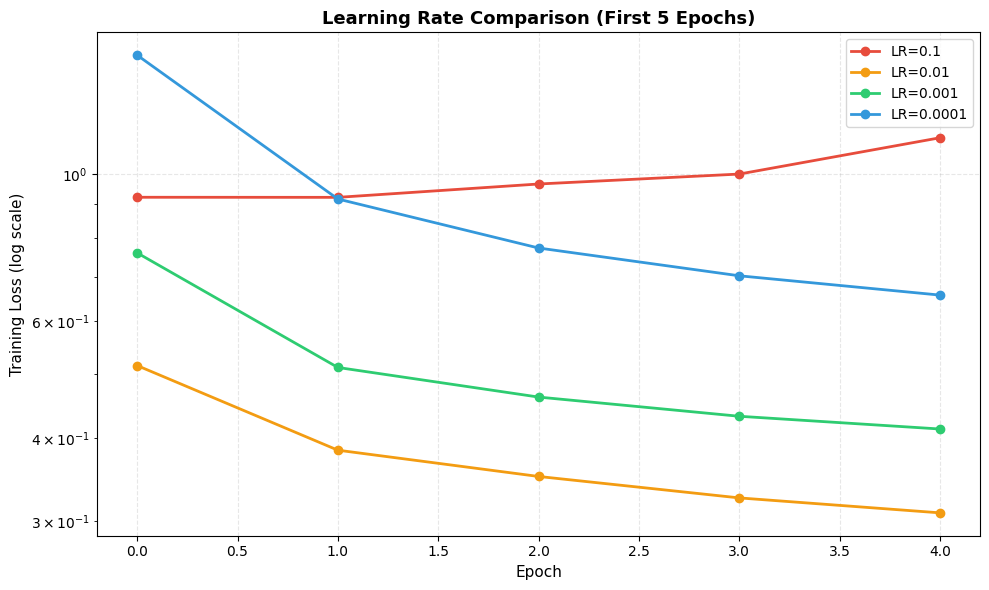

In [9]:
def plot_lr_comparison(lr_results):
    #for comparing training curves across learning rates
    plt.figure(figsize=(10, 6))
    
    colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
    for (lr, hist), color in zip(lr_results.items(), colors):
        plt.plot(hist['train_loss'], label=f'LR={lr}', marker='o', 
                color=color, linewidth=2)
    
    plt.xlabel('Epoch', fontsize=11)
    plt.ylabel('Training Loss (log scale)', fontsize=11)
    plt.title('Learning Rate Comparison (First 5 Epochs)', 
             fontsize=13, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.yscale('log')  # Log scale to see differences clearly
    plt.tight_layout()
    return plt.gcf()

fig2 = plot_lr_comparison(lr_results)
plt.show()

## 6.Results

### 6.1 Final Test Evalutaion

In [10]:
print("FINAL TEST EVALUATION:")
print(" "*60)

test_loss, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

print(f"• Test Loss: {test_loss:.4f}")
print(f"• Test Accuracy: {test_acc:.2f}%")

# Classification report
print(f"\n Classification Report:")
print(classification_report(
    test_labels, test_preds, 
    target_names=class_names,
    digits=3
))



print(" Generating Results Summary...")

#  Extract metrics from history 
final_train_loss = history['train_loss'][-1]
final_val_loss = history['val_loss'][-1]
final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]
initial_train_loss = history['train_loss'][0]
initial_val_loss = history['val_loss'][0]

#  Learning Rate Experiment Summary
lr_summary = []
for lr, hist in lr_results.items():
    lr_summary.append({
        'Learning Rate': lr,
        'Final Train Loss': hist['train_loss'][-1],
        'Final Val Loss': hist['val_loss'][-1],
        'Loss Reduction (5 epochs)': f"{hist['train_loss'][0]/hist['train_loss'][-1]:.2f}x"
    })
lr_df = pd.DataFrame(lr_summary)

#  Main Experiment Summary 
main_summary = pd.DataFrame({
    'Metric': [
        'Initial Train Loss', 'Final Train Loss', 'Loss Reduction',
        'Initial Val Loss', 'Final Val Loss',
        'Final Train Accuracy (%)', 'Final Val Accuracy (%)',
        'Test Accuracy (%)', 'Test Loss', 'Total Epochs'
    ],
    'Value': [
        f"{initial_train_loss:.4f}", f"{final_train_loss:.4f}", 
        f"{initial_train_loss/final_train_loss:.2f}x",
        f"{initial_val_loss:.4f}", f"{final_val_loss:.4f}",
        f"{final_train_acc:.2f}", f"{final_val_acc:.2f}",
        f"{test_acc:.2f}", f"{test_loss:.4f}", NUM_EPOCHS
    ]
})

# 4. Display Tables 
print("\n" + " " * 70)
print(" Results Summary")
print(" "*70)
print(main_summary.to_string(index=False))

print("\n" + " "*70)
print(" LEARNING RATE COMPARISON (First 5 Epochs)")
print(" "*70)
print(lr_df.to_string(index=False))



FINAL TEST EVALUATION:
                                                            
• Test Loss: 0.3343
• Test Accuracy: 87.85%

 Classification Report:
              precision    recall  f1-score   support

 T-shirt/top      0.851     0.825     0.838      1000
     Trouser      0.989     0.966     0.977      1000
    Pullover      0.812     0.780     0.796      1000
       Dress      0.866     0.893     0.879      1000
        Coat      0.780     0.833     0.806      1000
      Sandal      0.967     0.933     0.950      1000
       Shirt      0.693     0.683     0.688      1000
     Sneaker      0.912     0.957     0.934      1000
         Bag      0.968     0.967     0.967      1000
  Ankle boot      0.954     0.948     0.951      1000

    accuracy                          0.878     10000
   macro avg      0.879     0.879     0.879     10000
weighted avg      0.879     0.878     0.879     10000

 Generating Results Summary...

                                                        

### 6.2 Confusion Matrix

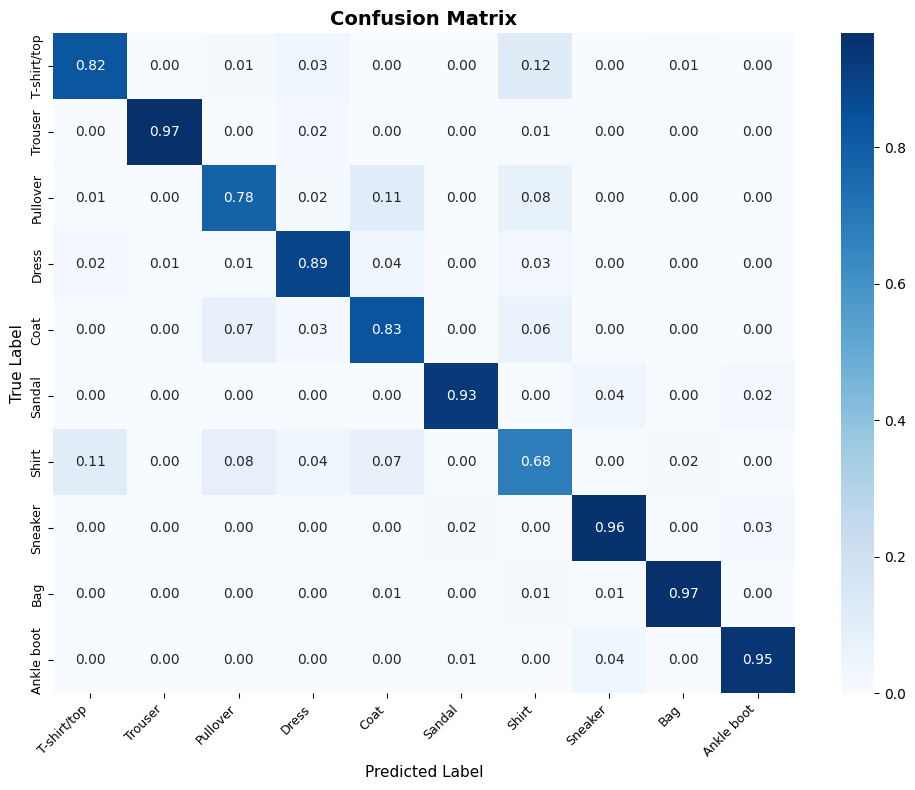

In [11]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    #Plot normalized confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=11)
    plt.xlabel('Predicted Label', fontsize=11)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    return plt.gcf()

# Plot confusion matrix
fig_cm = plot_confusion_matrix(test_labels, test_preds, class_names)
plt.show()

### 6.3 Result Visulaizations

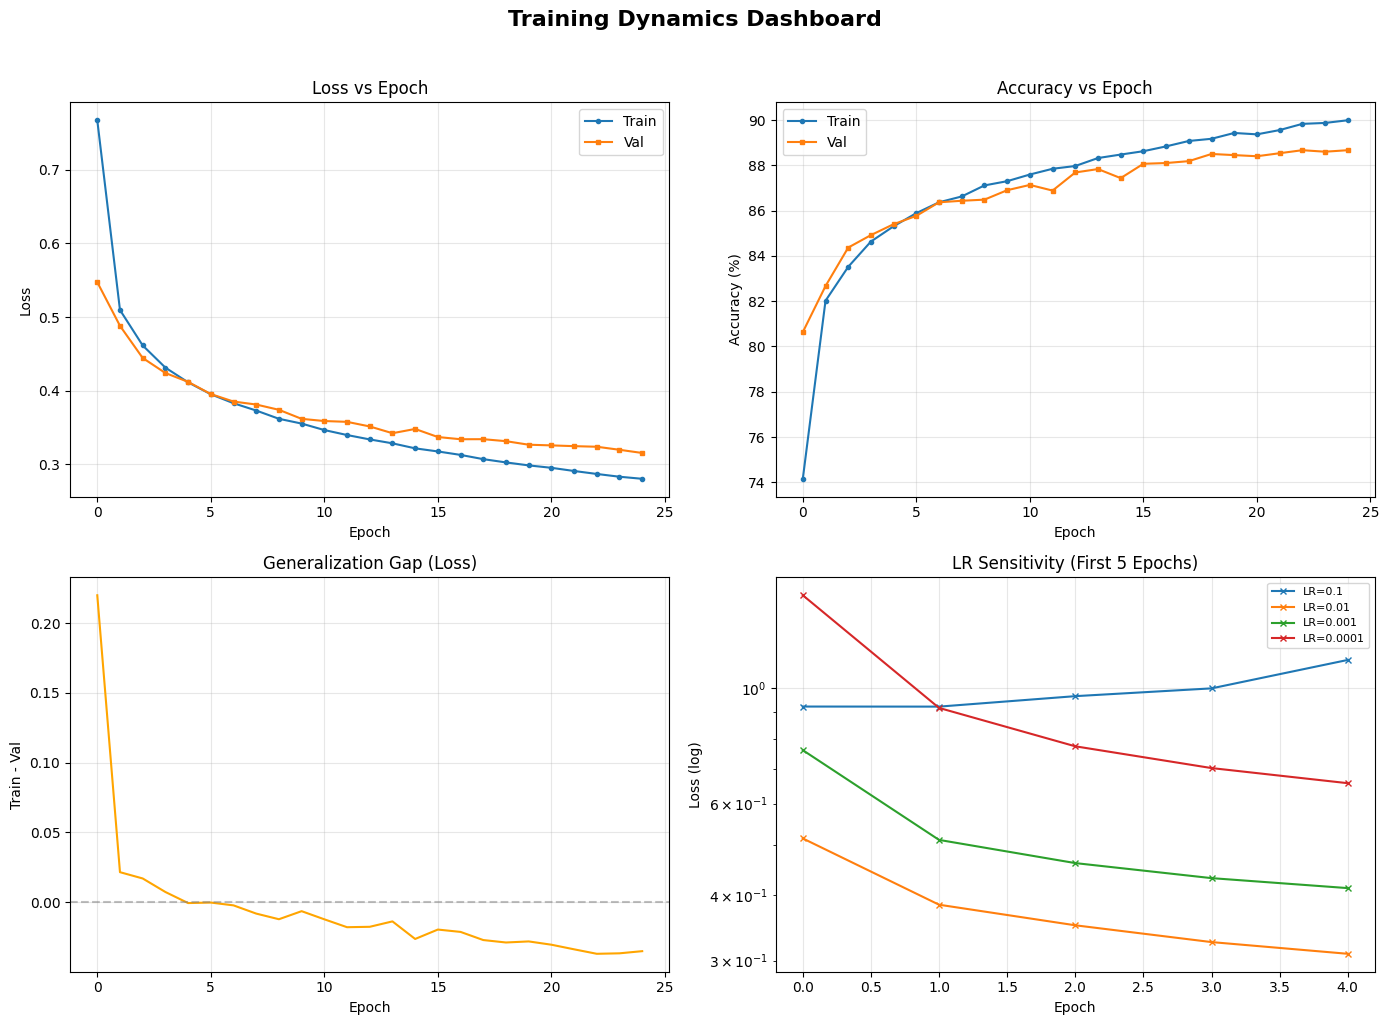

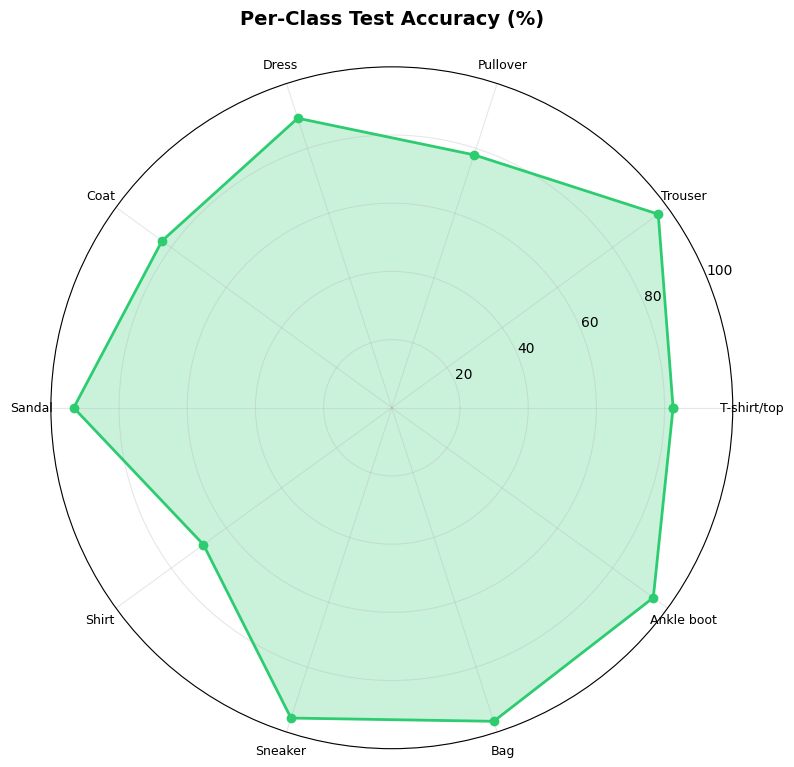

 Radar chart generated

★★★★★★★★★★★★★★★★★★★ FINAL METRICS SUMMARY★★★★★★★★★★★★★★★★★★★
  Test Accuracy     : 87.85%
  Test Loss         : 0.3343
  Best Val Accuracy : 88.67%
  Convergence Epoch : 25
  Parameters        : 203,530
                                                            


In [12]:


#  Combined Training Dynamics Plot 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Dynamics Dashboard', fontsize=16, fontweight='bold', y=1.02)

# (1,1) Loss curves
axes[0,0].plot(history['train_loss'], label='Train', marker='o', markersize=3)
axes[0,0].plot(history['val_loss'], label='Val', marker='s', markersize=3)
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
axes[0,0].set_title('Loss vs Epoch'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# (1,2) Accuracy curves
axes[0,1].plot(history['train_acc'], label='Train', marker='o', markersize=3)
axes[0,1].plot(history['val_acc'], label='Val', marker='s', markersize=3)
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Accuracy (%)')
axes[0,1].set_title('Accuracy vs Epoch'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# (2,1) Train-Val Gap (Overfitting indicator)
gap_loss = np.array(history['train_loss']) - np.array(history['val_loss'])
gap_acc = np.array(history['train_acc']) - np.array(history['val_acc'])
axes[1,0].plot(gap_loss, label='Loss Gap', color='orange')
axes[1,0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Train - Val')
axes[1,0].set_title('Generalization Gap (Loss)'); axes[1,0].grid(alpha=0.3)

# (2,2) Learning Rate Comparison Summary
for lr, hist in lr_results.items():
    axes[1,1].plot(hist['train_loss'], label=f'LR={lr}', marker='x', markersize=4)
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Loss (log)')
axes[1,1].set_title('LR Sensitivity (First 5 Epochs)')
axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3); axes[1,1].set_yscale('log')

plt.tight_layout()
plt.show()

#Radar Chart for Per-Class Accuracy 
try:
    from math import pi
    
    # Get per-class accuracy from confusion matrix
    cm = confusion_matrix(test_labels, test_preds)
    class_acc = np.diag(cm) / cm.sum(axis=1) * 100
    
    # Radar chart setup
    categories = class_names
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Close the loop
    
    # Values
    values = class_acc.tolist()
    values += values[:1]
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
    ax.plot(angles, values, 'o-', linewidth=2, color='#2ecc71')
    ax.fill(angles, values, alpha=0.25, color='#2ecc71')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=9)
    ax.set_ylim(0, 100)
    ax.set_title('Per-Class Test Accuracy (%)', size=14, fontweight='bold', y=1.05)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(" Radar chart generated")
except Exception as e:
    print(f" Radar chart skipped (optional): {e}")

#   Metrics Summary 
print("\n" + " FINAL METRICS SUMMARY".center(60, "★"))
print(f"  Test Accuracy     : {test_acc:.2f}%")
print(f"  Test Loss         : {test_loss:.4f}")
print(f"  Best Val Accuracy : {max(history['val_acc']):.2f}%")
print(f"  Convergence Epoch : {np.argmin(history['val_loss']) + 1}")
print(f"  Parameters        : {model.count_parameters():,}")
print(" " * 60)


## 8. Analysis & Discussion

### 8.1 What Worked
- **Model & regularization:** The 784 -> 256 -> 10 MLP with ReLU and 0.2 dropout balanced capacity and generalization went well. The train-val accuracy gap stayed under 1.3%, and test accuracy (87.85%) closely tracked validation,meanng dropout was doing its job.<br/><br/>
- **SGD + Momentum:** Training loss dropped over the 25 epochs, confirming momentum accelerated convergence and reduced oscillations effectively.<br/><br/>
- **Balanced dataset:** Near-equal class distribution of about 10% each kept training stable and didnt need class weighting.<br/><br/>
- **Visually distinct classes:** Trouser (F1: 0.977), Bag (0.967), and Ankle Boot (0.951) performed excellently , their unique feautures were easy to capture even in flattened pixel form.<br/><br/>

### 8.2 What Didn't Work
- **LR=0.1 was too aggressive:** Loss barely reduced (0.81×) and ended at 1.13 after 5 epochs, indicating the optimizer was overshooting. LR=0.01 was actually the fastest converger in the sensitivity experiment.<br/><br/>
- **Shirt/Pullover/Coat confusion:** These visually similar tops produced the weakest F1 scores (0.688, 0.796, 0.806). Flattening images to a 1D vector loses the spatial/textural features that were required to distinguish them , which is a fundamental MLP limitation.<br/><br/>
- **No early stopping or LR scheduling:** The model was still improving at epoch 25 (the final epoch), leaving performance on the table.<br/><br/>

### 8.3 Bias-Variance Observations
The model leans slightly toward **bias (underfitting)** rather than overfitting. The small train-val-test gap shows good generalization, but the ~88–90% accuracy ceiling reflects architectural limits. Thus,a single hidden layer with no spatial awareness was not a data or regularization problem.<br/>


## 9. Conclusion

- **Solid baseline :** 87.85% test accuracy with no data augmentation or LR scheduling confirms MLPs are competitive on structured benchmarks like Fashion-MNIST. <br/><br/>
- **Learning rate is the most critical hyperparameter :** LR=0.1 diverged, LR=0.0001 stalled, and LR=0.01 converged fastest -> a scheduler (step decay or cosine annealing) would improve over a fixed rate.<br/><br/>
- **Dropout successfully prevented overfitting :** The train-val gap stayed below 1.5% throughout, validating the 0.2 dropout rate for this model size.<br/><br/>
- **Spatial structure is the core bottleneck :** Shirt, Pullover, and Coat misclassifications are the direct consequences of flattening, whereas a CNN could close this gap by preserving local patterns.<br/><br/>
- **The model hadn't fully converged at epoch 25 :** Extending training with LR=0.01 and a decay schedule, or adding a second hidden layer, could actualy push accuracy past 92%.<br/>